In [18]:
# Importing package

import re
from collections import Counter
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
import arabic_reshaper
from bidi.algorithm import get_display
from matplotlib.font_manager import FontProperties
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    roc_curve
)

In [2]:
# Opening CSV file

df = pd.read_csv(r'A:\SentimentAnalyze\snappfood_comments.csv', encoding='utf-8', on_bad_lines="skip")
df.head(5)


,code,customerId,text,rating,date,feeling
0,p86152,130744,نون سیر خشک تلخ ،پیترا مخلوط بسیار بسیار بی کیفیت,2,۱۴۰۴/۱۲/۲۸,SAD
1,p86152,36864388,چیز برگر ارسال نشد,2,۱۴۰۴/۱۲/۲۸,SAD
2,p86152,4372759,حتی در زمان جنگ و ماه رمضان هم کیفیت خوب بود,10,۱۴۰۴/۱۲/۲۷,HAPPY
3,p86152,6947568,عالی بود و به موقع رسید,10,۱۴۰۴/۱۲/۲۶,HAPPY
4,p86152,19051568,مغایرت در سفارش و عدم توجه به توضیحات همراه با...,2,۱۴۰۴/۱۲/۲۶,SAD


In [3]:
df['rating'].value_counts()


rating
10    41691
8      4549
6      2344
0      1874
2      1769
4      1011
5        16
3         4
Name: count, dtype: int64

In [4]:
# Keeping samples with a valid label

df['rating'] = df['rating'] / 2
df['rating'] = df['rating'].astype(int)
df = df[df['rating'] != 0]
df['rating'].value_counts()

rating
5    41691
4     4549
3     2344
1     1773
2     1027
Name: count, dtype: int64

In [5]:
# Keeping valueable comments

df['text_length'] = df['text'].str.len()
df = df[df['text_length'] >= 5]
df = df.drop(columns=['text_length'])

In [6]:
# Cleaning noisy text

def clean_persian_text(text):
    if not isinstance(text, str):
        return ""
    #removing links and @s
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    
    #replacing arabic charachters with their persian replica
    text = text.replace("ي", "ی").replace("ك", "ک")
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text) #only persian stuff, numbers and spaces
    
    #leveling spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning dataset in progress ...")
df['cleaned_text'] = df['text'].apply(clean_persian_text) #applying operatio to all values
print("Its done! ")

Cleaning dataset in progress ...
Its done! 


In [7]:
# Creating vocabulary

all_words = []
for text in df['cleaned_text']:
    all_words.extend(text.split()) #text -> list of word -> add to all_words

word_counts = Counter(all_words) #output a dic: (word (key): cout (value))
min_freq = 2 #words whould have atleast 2 characters to be added
vocab = {"<PAD>": 0, "<UNK>": 1} #helping tokens for padding and unknowns

idx = 2
for word, count in word_counts.items():
    if count >= min_freq and len(word) > 2:
        vocab[word] = idx
        idx += 1


VOCAB_SIZE = len(vocab)
print(f"Vocabulary has been made succesfully with VOCAB_SIZE of {VOCAB_SIZE}.")

Vocabulary has been made succesfully with VOCAB_SIZE of 6489.


In [8]:
# Tokenization & Padding

MAX_SEQ_LEN = 50

def tokenize_and_pad(text, vocab, max_len):
    words = text.split()
    # replacing unknown word
    tokens = [vocab.get(word, vocab["<UNK>"]) for word in words]
    
    # padding
    if len(tokens) < max_len:
        tokens = tokens + [vocab["<PAD>"]] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

print("Tokenizing...")
X_all = np.array([tokenize_and_pad(t, vocab, MAX_SEQ_LEN) for t in df['cleaned_text']])#111111111
y_all = df['rating'].values - 1 # labels from 1 to 5
print("Its done!")

Tokenizing...
Its done!


In [ ]:
# Splitting dataset with balanced disterbution of labels

X_train, X_valtest, y_train, y_valtest = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all)

X_val, X_test, y_val, y_test = train_test_split(
    X_all, y_all, test_size=0.5, random_state=42, stratify=y_all)


In [10]:
# Dataset and Data loader

class SnappFoodDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = SnappFoodDataset(X_train, y_train)
val_dataset = SnappFoodDataset(X_val, y_val)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples count: {len(train_dataset)} | Validation samples count {len(val_dataset)}")

Training samples count: 41098 | Validation samples count 7253


In [11]:
# Defining Expert and Feed Forward

class Expert(nn.Module):
    def __init__(self, d_model, d_hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_model),
            nn.Dropout(0.1)
        )
    def forward(self, x):
        return self.net(x)

In [12]:
# Defining MoE Layer

class SparseMoELayer(nn.Module):
    def __init__(self, d_model, d_hidden, num_experts, top_k=1, aux_loss_coef=0.01):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.aux_loss_coef = aux_loss_coef
        
        self.experts = nn.ModuleList([Expert(d_model, d_hidden) for _ in range(num_experts)])
        self.router = nn.Linear(d_model, num_experts)
        
        # defining variable for last routing situation (for visualization)
        self.last_routing_weights = None
        self.current_aux_loss = 0.0

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        B, S, D = x.shape
        x_flat = x.view(-1, D)  # [B*S, D]
        
        # calculating logits and routor probabilities
        router_logits = self.router(x_flat)  # [B*S, num_experts]
        routing_weights = F.softmax(router_logits, dim=-1)  # [B*S, num_experts]
        
        # saving wights for visualization
        self.last_routing_weights = routing_weights.detach().view(B, S, self.num_experts)
        
        # selecting K-Top experts
        topk_weights, topk_indices = torch.topk(routing_weights, self.top_k, dim=-1)
        
        # renormalizing selected weights
        topk_weights = topk_weights / (topk_weights.sum(dim=-1, keepdim=True) + 1e-20)
        
        # Auxiliary loss for balancing token distebution
        # routor bias to each expert
        f_g = routing_weights.mean(dim=0) 
        # real percentage of tokens to each expert 
        f_c = torch.zeros(self.num_experts, device=x.device)
        for i in range(self.num_experts):
            f_c[i] = (topk_indices == i).float().mean()
        self.current_aux_loss = self.num_experts * torch.sum(f_g * f_c) * self.aux_loss_coef
        
        # applying experts calculation
        out_flat = torch.zeros_like(x_flat)
        for i, expert in enumerate(self.experts):
            mask = (topk_indices == i).any(dim=-1)
            if mask.any():
                token_inputs = x_flat[mask]
                expert_outputs = expert(token_inputs)
                
                # applying routhor probabilities on each expert's output
                weight_mask = (topk_indices == i)
                extracted_weights = topk_weights[weight_mask].unsqueeze(-1)
                
                out_flat[mask] += expert_outputs * extracted_weights
                
        return out_flat.view(B, S, D)


In [13]:
# Final classifier model with MoE layer

class MoETextClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, d_hidden, num_experts, max_seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)
        
        # a self-attention layer for extracting basic relations
        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=4, batch_first=True)
        
        # MoE Layer
        self.moe = SparseMoELayer(d_model, d_hidden, num_experts, top_k=1)
        
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        
        # outpot layer with 5 class
        self.fc_out = nn.Linear(d_model, 5) 

    def forward(self, text_tokens):
        B, S = text_tokens.shape
        positions = torch.arange(0, S, device=text_tokens.device).unsqueeze(0).expand(B, S)
        
        x = self.embedding(text_tokens) + self.pos_embedding(positions)
        
        # Residual Connection
        attn_out, _ = self.attention(x, x, x)
        x = self.layer_norm1(x + attn_out)
        
        # Residual Connection + MoE
        moe_out = self.moe(x)
        x = self.layer_norm2(x + moe_out)
        
        # Pooling: averaging text's length for setting a constant vector
        x_pooled = x.mean(dim=1) 
        
        # Final result
        logits = self.fc_out(x_pooled)
        return logits


class TextDataset(Dataset):
    def __init__(self, tokenized_sequences, labels):
        self.sequences = torch.tensor(tokenized_sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def train_moe_model(model, train_loader, optimizer, criterion, epochs=3, device='cuda'):
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_preds = 0
        total_samples = 0
        
        for batch_tokens, batch_labels in train_loader:
            batch_tokens, batch_labels = batch_tokens.to(device), batch_labels.to(device)
            
            optimizer.zero_grad()
            
            # model output
            logits = model(batch_tokens)
            
            # calculating loss
            cls_loss = criterion(logits, batch_labels)
            aux_loss = model.moe.current_aux_loss
            
            # total loss
            loss = cls_loss + aux_loss
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * batch_tokens.size(0)
            preds = torch.argmax(logits, dim=-1)
            correct_preds += (preds == batch_labels).sum().item()
            total_samples += batch_labels.size(0)
            
        epoch_loss = total_loss / total_samples
        epoch_acc = correct_preds / total_samples
        print(f"Epoch {epoch+1}/{epochs} -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

def visualize_persian_routing(model, sentence, tokenizer_func, max_len, device='cuda'):
    model.eval()
    model.to(device)

    # tokenizing
    tokens_list, word_labels = tokenizer_func(sentence, max_len)
    input_tensor = torch.tensor([tokens_list], dtype=torch.long).to(device)

    # data going through the model
    with torch.no_grad():
        logits = model(input_tensor)
        prediction = torch.argmax(logits, dim=-1).item()

    # extracting routing matrix
    routing_matrix = model.moe.last_routing_weights[0].cpu().numpy()
    actual_len = len(word_labels)
    routing_matrix = routing_matrix[:actual_len, :]

    # setting font (for persian visualization)
    font_path = r'c:\Windows\Fonts\ARIAL.TTF' 
    try:
        persian_font = FontProperties(fname=font_path, size=13)
        title_font = FontProperties(fname=font_path, size=15, weight='bold')
    except Exception as e:
        persian_font = FontProperties(size=12)
        title_font = FontProperties(size=14)

    # reshapeing persian words (for persian visualization)
    fixed_word_labels = []
    for word in word_labels:
        reshaped_text = arabic_reshaper.reshape(word) 
        bidi_text = get_display(reshaped_text)        
        fixed_word_labels.append(bidi_text)

    # plotting heatmap
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    ax = sns.heatmap(
        routing_matrix,
        annot=True, 
        cmap="YlGnBu", 
        xticklabels=[f"Expert {i+1}" for i in range(model.moe.num_experts)],
        yticklabels=fixed_word_labels, 
        cbar_kws={'label': 'Routing Weight (Softmax)'},
        linewidths=0.7,
        fmt=".2f"
    )

    # applying persian font
    for label in ax.get_yticklabels():
        label.set_fontproperties(persian_font)

    # title
    sentiment = f"{prediction + 1} ستاره"
    raw_title = f"نقشه فعال‌سازی متخصص‌ها\nورودی: '{sentence}'\nپیش بینی: {sentiment}"
    fixed_title = get_display(arabic_reshaper.reshape(raw_title))

    plt.title(fixed_title, fontproperties=title_font, pad=15)
    plt.xlabel("Specialized Experts", fontsize=11)

    # ylabel
    fixed_ylabel = get_display(arabic_reshaper.reshape("توکن‌های فارسی"))
    plt.ylabel(fixed_ylabel, fontproperties=persian_font)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

def mock_tokenizer(sentence, max_len):
    words = sentence.split()
    # our real tokenizer maps each word to a real ids (but here is just a random id)
    tokens = [np.random.randint(1, 1000) for _ in words] 
    
    # padding
    if len(tokens) < max_len:
        tokens = tokens + [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
        words = words[:max_len]
    return tokens, words



In [14]:
from sklearn.utils.class_weight import compute_class_weight

# hyperparameters
D_MODEL = 64
D_HIDDEN = 128
NUM_EXPERTS = 4
EPOCHS = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# making an instance of our model
model = MoETextClassifier(
    vocab_size=VOCAB_SIZE, 
    d_model=D_MODEL, 
    d_hidden=D_HIDDEN, 
    num_experts=NUM_EXPERTS, 
    max_seq_len=MAX_SEQ_LEN
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# fixing unbalanced data
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_all), 
    y=y_all
)

print(np.unique(y_all))

# reforming weights to tensor and giving it to device
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

# inputting weights tensor to loss function
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

[0 1 2 3 4]


In [15]:
# performing training
print(f"Trainig phase has started: {DEVICE}")
train_moe_model(model, train_loader, optimizer, criterion, epochs=EPOCHS, device=DEVICE)

# live test function
def snappfood_tokenizer_bridge(sentence, max_len):
    cleaned = clean_persian_text(sentence)
    words = cleaned.split()
    tokens = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(tokens) < max_len:
        tokens = tokens + [vocab["<PAD>"]] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
        words = words[:max_len]
    return tokens, words

Trainig phase has started: cpu
Epoch 1/10 -> Loss: 1.3705 | Accuracy: 0.6002
Epoch 2/10 -> Loss: 1.1967 | Accuracy: 0.7046
Epoch 3/10 -> Loss: 1.1404 | Accuracy: 0.7261
Epoch 4/10 -> Loss: 1.0914 | Accuracy: 0.7376
Epoch 5/10 -> Loss: 1.0437 | Accuracy: 0.7453
Epoch 6/10 -> Loss: 1.0003 | Accuracy: 0.7506
Epoch 7/10 -> Loss: 0.9506 | Accuracy: 0.7603
Epoch 8/10 -> Loss: 0.9036 | Accuracy: 0.7639
Epoch 9/10 -> Loss: 0.8471 | Accuracy: 0.7687
Epoch 10/10 -> Loss: 0.8054 | Accuracy: 0.7693


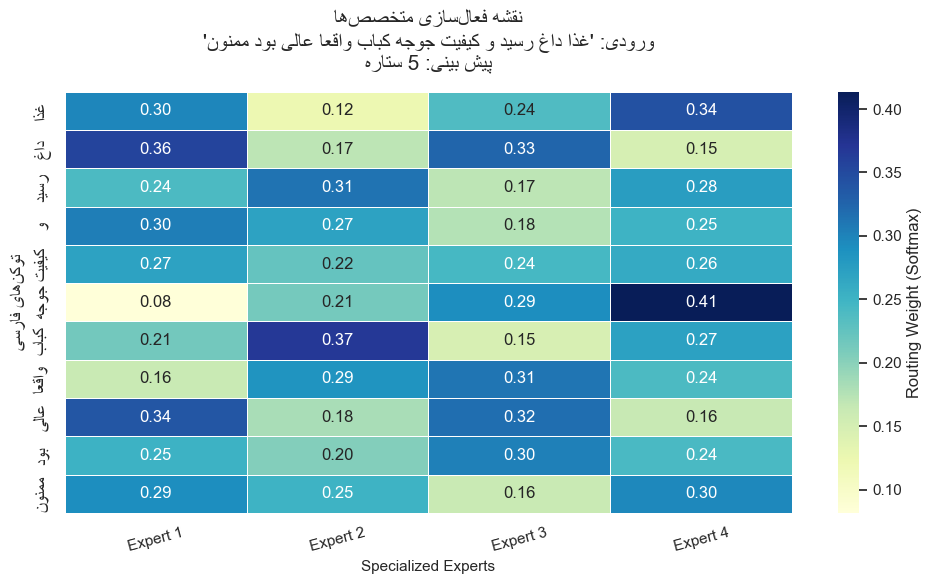

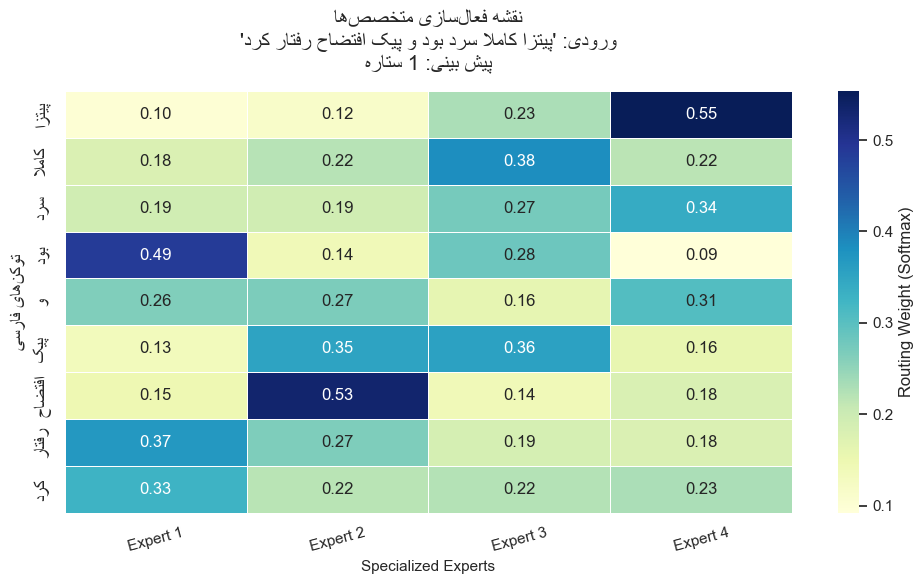

In [16]:
# 1st sample comment (obvious 5 stars)
sample_positive = "غذا داغ رسید و کیفیت جوجه کباب واقعا عالی بود ممنون"
visualize_persian_routing(model, sample_positive, snappfood_tokenizer_bridge, MAX_SEQ_LEN, device=DEVICE)

# 2nd sample comment (obvious 1 stars)
sample_negative = "پیتزا کاملا سرد بود و پیک افتضاح رفتار کرد"
visualize_persian_routing(model, sample_negative, snappfood_tokenizer_bridge, MAX_SEQ_LEN, device=DEVICE)

In [17]:
def discover_expert_specialties(model, data_loader, vocab_dict, top_n=15, device='cuda'):
    model.eval()
    model.to(device)
    
    # reverce dictionery for converting id to word
    idx_to_word = {idx: word for word, idx in vocab_dict.items()}
    
    # a counter for each expert
    from collections import Counter
    expert_word_counts = {i: Counter() for i in range(model.moe.num_experts)}
    
    print("Analyzing... \n")
    
    with torch.no_grad():
        for batch_tokens, _ in data_loader:
            batch_tokens = batch_tokens.to(device)
            
            _ = model(batch_tokens) 
            
            routing_weights = model.moe.last_routing_weights
            
            best_experts = torch.argmax(routing_weights, dim=-1).cpu().numpy()
            tokens_np = batch_tokens.cpu().numpy()
            
            for b in range(tokens_np.shape[0]):
                for s in range(tokens_np.shape[1]):
                    token_id = tokens_np[b, s]
                    expert_id = best_experts[b, s]
                    
                    if token_id != vocab_dict.get("<PAD>") and token_id != vocab_dict.get("<UNK>"):
                        word = idx_to_word.get(token_id, "")
                        expert_word_counts[expert_id][word] += 1
                        

    for i in range(model.moe.num_experts):
        print(f"Expert {i+1} (Most commen word for this expert):")
        top_words = expert_word_counts[i].most_common(top_n)
        words_list = [f"{w} ({c} times)" for w, c in top_words]
        print(" | ".join(words_list))
        print("-" * 60)

discover_expert_specialties(model, val_loader, vocab, top_n=5, device=DEVICE)

Analyzing... 

Expert 1 (Most commen word for this expert):
بود (2110 times) | همیشه (1489 times) | عالی (711 times) | غذا (601 times) | شیلا (388 times)
------------------------------------------------------------
Expert 2 (Most commen word for this expert):
عالی (671 times) | خوشمزه (602 times) | گرم (495 times) | خوب (429 times) | مثل (365 times)
------------------------------------------------------------
Expert 3 (Most commen word for this expert):
بود (2068 times) | عالی (957 times) | کیفیت (486 times) | پیک (318 times) | سفارش (248 times)
------------------------------------------------------------
Expert 4 (Most commen word for this expert):
مثل (946 times) | عالی (834 times) | خوب (683 times) | خیلی (625 times) | پیتزا (460 times)
------------------------------------------------------------
